In [ ]:
import sys
import os

import numpy as np
from ripser import ripser
from persim import plot_diagrams


from opt_einsum import contract

from diffusion_geometry.core.geometry.diffusion_geometry import DiffusionGeometry
sys.path.append(os.path.abspath('..'))  # Add parent directory to path

import numpy as np
# from diffusion_geometry.src.visualisation import *
from plotly.subplots import make_subplots
# from diffusion_geometry import Function, VectorField, Form
from generate_data import gen_2d_data
# from diffusion_geometry import DiffusionGeometry
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.textpath import TextPath
from matplotlib.font_manager import FontProperties
from matplotlib.path import Path
import pandas as pd
import matplotlib.pyplot as plt
from figures.generate_data import gen_3d_data
import time
import numpy as np

import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault) 
plt.rcParams['font.family'] = 'serif'
mpl.rcParams['mathtext.fontset'] = 'cm'


dot_colors = ["#e32636","#166dde", "#d3d3d3",]

def sample_torus(minor_radius=1, major_radius=2, n=1, seed=0):
    torus_data = gen_3d_data(kind = 'torus', minor_radius=minor_radius, n=n, major_radius=major_radius, noise = 0.0, seed = seed)[0]
    return torus_data

def final_benchmark_function(
    *,
    setup_fn,
    setup_params: dict[str, list],
    run_fn,
    run_fn_kwargs: dict[str, list],
    repeats: int,
    output_csv: str | None = None,
):
    # ---- length check ----
    lengths = {len(v) for v in setup_params.values()}
    lengths |= {len(v) for v in run_fn_kwargs.values()}

    if len(lengths) != 1:
        raise ValueError("All parameter lists must have the same length")

    num_runs = lengths.pop()
    print(f"Starting benchmark: {num_runs} configurations, {repeats} repeats each", flush=True)

    rows = []

    # ---- main loop ----
    for i in range(num_runs):
        setup_kwargs = {k: v[i] for k, v in setup_params.items()}
        run_kwargs = {k: v[i] for k, v in run_fn_kwargs.items()}

        print(f"\nConfiguration {i+1}/{num_runs}: {setup_kwargs} + {run_kwargs}", flush=True)

        for r in range(repeats):
            print(f"  Repeat {r+1}/{repeats}", flush=True)

            data = setup_fn(**setup_kwargs)

            t0 = time.perf_counter()
            run_fn(data, **run_kwargs)
            t = time.perf_counter() - t0

            print(f"    Time: {t:.6e} s", flush=True)

            rows.append({
                **setup_kwargs,
                **run_kwargs,
                "repeat": r,
                "time": t,
            })

        # Save CSV after each configuration
        if output_csv is not None:
            pd.DataFrame(rows).to_csv(output_csv, mode="w", header=True, index=False)
            print(f"  Saved progress to {output_csv}", flush=True)

    print("\nBenchmark complete.", flush=True)
    return pd.DataFrame(rows)

def analyse_benchmark(file_name):
    df = pd.read_csv(file_name)
    # df = pd.read_csv("benchmarking_results/test_benchmark.csv")

    df['grp'] = (df['repeat'] == 0).cumsum() - 1 
    grouped = df.groupby('grp')
    stats = grouped["time"].agg(["mean", "std"]).reset_index()

    representatives = grouped.first().reset_index()
    representatives = representatives.merge(stats, on="grp")

    sizes = grouped.size().reset_index(name="count")
    representatives = representatives.merge(sizes, on="grp")

    representatives = representatives.drop(columns=["repeat"])

    return representatives, df

def sample_nsphere(d=2, num_samples=10):
    # Sample from a standard normal in R^{n+1}
    x = np.random.normal(size=(num_samples, d + 1))
    # Normalize each vector to lie on the unit sphere
    x /= np.linalg.norm(x, axis=1, keepdims=True)
    return x


def run_ripser(data, maxdim=1):
    diagrams = ripser(data, maxdim=maxdim)['dgms']
    return diagrams

def run_cum_dg(data, maxdim=1):
    dg = DiffusionGeometry.from_point_cloud(data, knn_kernel=32,)
    for dim in range(maxdim+1):
        eig_values, forms_1 = dg.laplacian(dim).spectrum(return_eigenvectors=True)

def run_isolated_dg(data, maxdim=1):
    dg = DiffusionGeometry.from_point_cloud(data, knn_kernel=32,)
    eig_values, forms_1 = dg.laplacian(maxdim).spectrum(return_eigenvectors=True)



## Scaling vs $n$




In [ ]:
n_scaling_setup_params = {
    "n": [200, 500,1000,1500,2000,2500,3000,3500,4000,5000,6000,7000, 8000,9000,10000,11000,12000]
}

n_scaling_ripser_params = {
    "maxdim": np.ones_like(n_scaling_setup_params["n"]) * 2,
}

final_benchmark_function(
    setup_fn=sample_torus,
    setup_params=n_scaling_setup_params,
    run_fn=run_cum_dg,
    run_fn_kwargs=n_scaling_ripser_params,
    repeats=20,
    output_csv="benchmarks/dg_H_2_n_scaling.csv"
)

In [ ]:
n_scaling_setup_params = {
    "n": [200]
}

n_scaling_ripser_params = {
    "maxdim": np.ones_like(n_scaling_setup_params["n"]) * 1,
}

final_benchmark_function(
    setup_fn=sample_torus,
    setup_params=n_scaling_setup_params,
    run_fn=run_ripser,
    run_fn_kwargs=n_scaling_ripser_params,
    repeats=20,
    output_csv="benchmarks/additional.csv"
)

In [ ]:
n_scaling_setup_params = {
    "n": [500,1000,1500,2000,2500,3000,3500,4000,5000,6000,7000, 8000,9000,10000,11000,12000]
}

n_scaling_ripser_params = {
    "maxdim": np.ones_like(n_scaling_setup_params["n"]) * 1,
}

final_benchmark_function(
    setup_fn=sample_torus,
    setup_params=n_scaling_setup_params,
    run_fn=run_cum_dg,
    run_fn_kwargs=n_scaling_ripser_params,
    repeats=20,
    output_csv="benchmarks/dg_H_1_n_scaling.csv"
)

In [ ]:
n_scaling_setup_params = {
    "n": [500,1000,1500,2000,2500,3000,3500,4000,5000,6000,7000, 8000,9000,10000,11000,12000]
}

n_scaling_ripser_params = {
    "maxdim": np.ones_like(n_scaling_setup_params["n"]) * 0,
}

final_benchmark_function(
    setup_fn=sample_torus,
    setup_params=n_scaling_setup_params,
    run_fn=run_cum_dg,
    run_fn_kwargs=n_scaling_ripser_params,
    repeats=20,
    output_csv="benchmarks/dg_H_0_n_scaling.csv"
)

In [ ]:
n_scaling_setup_params = {
    "n": [500,1000,1500,2000,2500,3000,3500,4000]
}

n_scaling_ripser_params = {
    "maxdim": np.ones_like(n_scaling_setup_params["n"]) * 1,
}

final_benchmark_function(
    setup_fn=sample_torus,
    setup_params=n_scaling_setup_params,
    run_fn=run_ripser,
    run_fn_kwargs=n_scaling_ripser_params,
    repeats=20,
    output_csv="benchmarks/ripser_H_1_n_scaling.csv"
)

In [ ]:
n_scaling_setup_params = {
    "n": [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000]
}

n_scaling_ripser_params = {
    "maxdim": np.ones_like(n_scaling_setup_params["n"]) * 0,
}

final_benchmark_function(
    setup_fn=sample_torus,
    setup_params=n_scaling_setup_params,
    run_fn=run_ripser,
    run_fn_kwargs=n_scaling_ripser_params,
    repeats=20,
    output_csv="benchmarks/ripser_H_0_n_scaling.csv"
)

In [ ]:
n_scaling_setup_params = {
    "n": [500,1000,1500,2000,2500,3000,3500,4000,5000,6000,7000, 8000,9000,10000,11000,12000]
}

n_scaling_ripser_params = {
    "maxdim": np.ones_like(n_scaling_setup_params["n"]) * 0,
}

final_benchmark_function(
    setup_fn=sample_torus,
    setup_params=n_scaling_setup_params,
    run_fn=run_isolated_dg,
    run_fn_kwargs=n_scaling_ripser_params,
    repeats=20,
    output_csv="benchmarks/dg_H_0_n_isolated_scaling.csv"
)

In [2]:
n_scaling_setup_params = {
    "n": [500,1000,1500,2000,2500,3000,3500,4000,5000,6000,7000, 8000,9000,10000,11000,12000]
}

n_scaling_ripser_params = {
    "maxdim": np.ones_like(n_scaling_setup_params["n"]) * 1,
}

final_benchmark_function(
    setup_fn=sample_torus,
    setup_params=n_scaling_setup_params,
    run_fn=run_isolated_dg,
    run_fn_kwargs=n_scaling_ripser_params,
    repeats=20,
    output_csv="benchmarks/dg_H_1_n_isolated_scaling.csv"
)

Starting benchmark: 16 configurations, 20 repeats each

Configuration 1/16: {'n': 500} + {'maxdim': np.int64(1)}
  Repeat 1/20
    Time: 6.569713e-02 s
  Repeat 2/20
    Time: 4.996108e-02 s
  Repeat 3/20
    Time: 4.913487e-02 s
  Repeat 4/20
    Time: 5.075296e-02 s
  Repeat 5/20
    Time: 4.986371e-02 s
  Repeat 6/20
    Time: 4.892333e-02 s
  Repeat 7/20
    Time: 4.886971e-02 s
  Repeat 8/20
    Time: 5.018650e-02 s
  Repeat 9/20
    Time: 5.085800e-02 s
  Repeat 10/20
    Time: 5.146592e-02 s
  Repeat 11/20
    Time: 4.968417e-02 s
  Repeat 12/20
    Time: 4.963800e-02 s
  Repeat 13/20
    Time: 5.033479e-02 s
  Repeat 14/20
    Time: 5.125150e-02 s
  Repeat 15/20
    Time: 4.945275e-02 s
  Repeat 16/20
    Time: 4.955287e-02 s
  Repeat 17/20
    Time: 4.880021e-02 s
  Repeat 18/20
    Time: 4.906533e-02 s
  Repeat 19/20
    Time: 4.982204e-02 s
  Repeat 20/20
    Time: 5.021133e-02 s
  Saved progress to benchmarks/dg_H_1_n_isolated_scaling.csv

Configuration 2/16: {'n': 1000} + 

,n,maxdim,repeat,time
0,500,1,0,0.065697
1,500,1,1,0.049961
2,500,1,2,0.049135
3,500,1,3,0.050753
4,500,1,4,0.049864
...,...,...,...,...
315,12000,1,15,1.366403
316,12000,1,16,1.378167
317,12000,1,17,1.432311
318,12000,1,18,1.287950


In [ ]:
n_scaling_setup_params = {
    "n": [200,500,1000,1500,2000,2500,3000,3500,4000,5000,6000,7000, 8000,9000,10000,11000,12000]
}

n_scaling_ripser_params = {
    "maxdim": np.ones_like(n_scaling_setup_params["n"]) * 2,
}

final_benchmark_function(
    setup_fn=sample_torus,
    setup_params=n_scaling_setup_params,
    run_fn=run_isolated_dg,
    run_fn_kwargs=n_scaling_ripser_params,
    repeats=20,
    output_csv="benchmarks/dg_H_2_n_isolated_scaling.csv"
)

In [7]:
n_scaling_setup_params = {
    "n": [200]
}

n_scaling_ripser_params = {
    "maxdim": np.ones_like(n_scaling_setup_params["n"]) * 0,
}

final_benchmark_function(
    setup_fn=sample_torus,
    setup_params=n_scaling_setup_params,
    run_fn=run_isolated_dg,
    run_fn_kwargs=n_scaling_ripser_params,
    repeats=20,
    output_csv="benchmarks/additional.csv"
)

Starting benchmark: 1 configurations, 20 repeats each

Configuration 1/1: {'n': 200} + {'maxdim': np.int64(0)}
  Repeat 1/20
    Time: 2.751262e-02 s
  Repeat 2/20
    Time: 1.953267e-02 s
  Repeat 3/20
    Time: 5.126246e-02 s
  Repeat 4/20
    Time: 2.787962e-02 s
  Repeat 5/20
    Time: 1.777063e-02 s
  Repeat 6/20
    Time: 1.789708e-02 s
  Repeat 7/20
    Time: 1.773217e-02 s
  Repeat 8/20
    Time: 1.765708e-02 s
  Repeat 9/20
    Time: 1.838825e-02 s
  Repeat 10/20
    Time: 1.870983e-02 s
  Repeat 11/20
    Time: 1.875442e-02 s
  Repeat 12/20
    Time: 1.749921e-02 s
  Repeat 13/20
    Time: 1.820600e-02 s
  Repeat 14/20
    Time: 1.718425e-02 s
  Repeat 15/20
    Time: 1.801092e-02 s
  Repeat 16/20
    Time: 1.716246e-02 s
  Repeat 17/20
    Time: 1.723058e-02 s
  Repeat 18/20
    Time: 1.816938e-02 s
  Repeat 19/20
    Time: 1.759967e-02 s
  Repeat 20/20
    Time: 1.828213e-02 s
  Saved progress to benchmarks/additional.csv

Benchmark complete.


,n,maxdim,repeat,time
0,200,0,0,0.027513
1,200,0,1,0.019533
2,200,0,2,0.051262
3,200,0,3,0.027880
4,200,0,4,0.017771
5,200,0,5,0.017897
6,200,0,6,0.017732
7,200,0,7,0.017657
8,200,0,8,0.018388
9,200,0,9,0.018710


## Scaling vs d

In [ ]:
d_scaling_setup_params = {
    "d": [1,2,3,4],
    "num_samples": [100, 100, 100, 100]
}

d_scaling_ripser_params = {
    "maxdim": d_scaling_setup_params["d"],
}

final_benchmark_function(
    setup_fn=sample_nsphere,
    setup_params=d_scaling_setup_params,
    run_fn=run_ripser,
    run_fn_kwargs=d_scaling_ripser_params,
    repeats=20,
    output_csv="benchmarks/cumulative_ripser_d_scaling.csv"
)

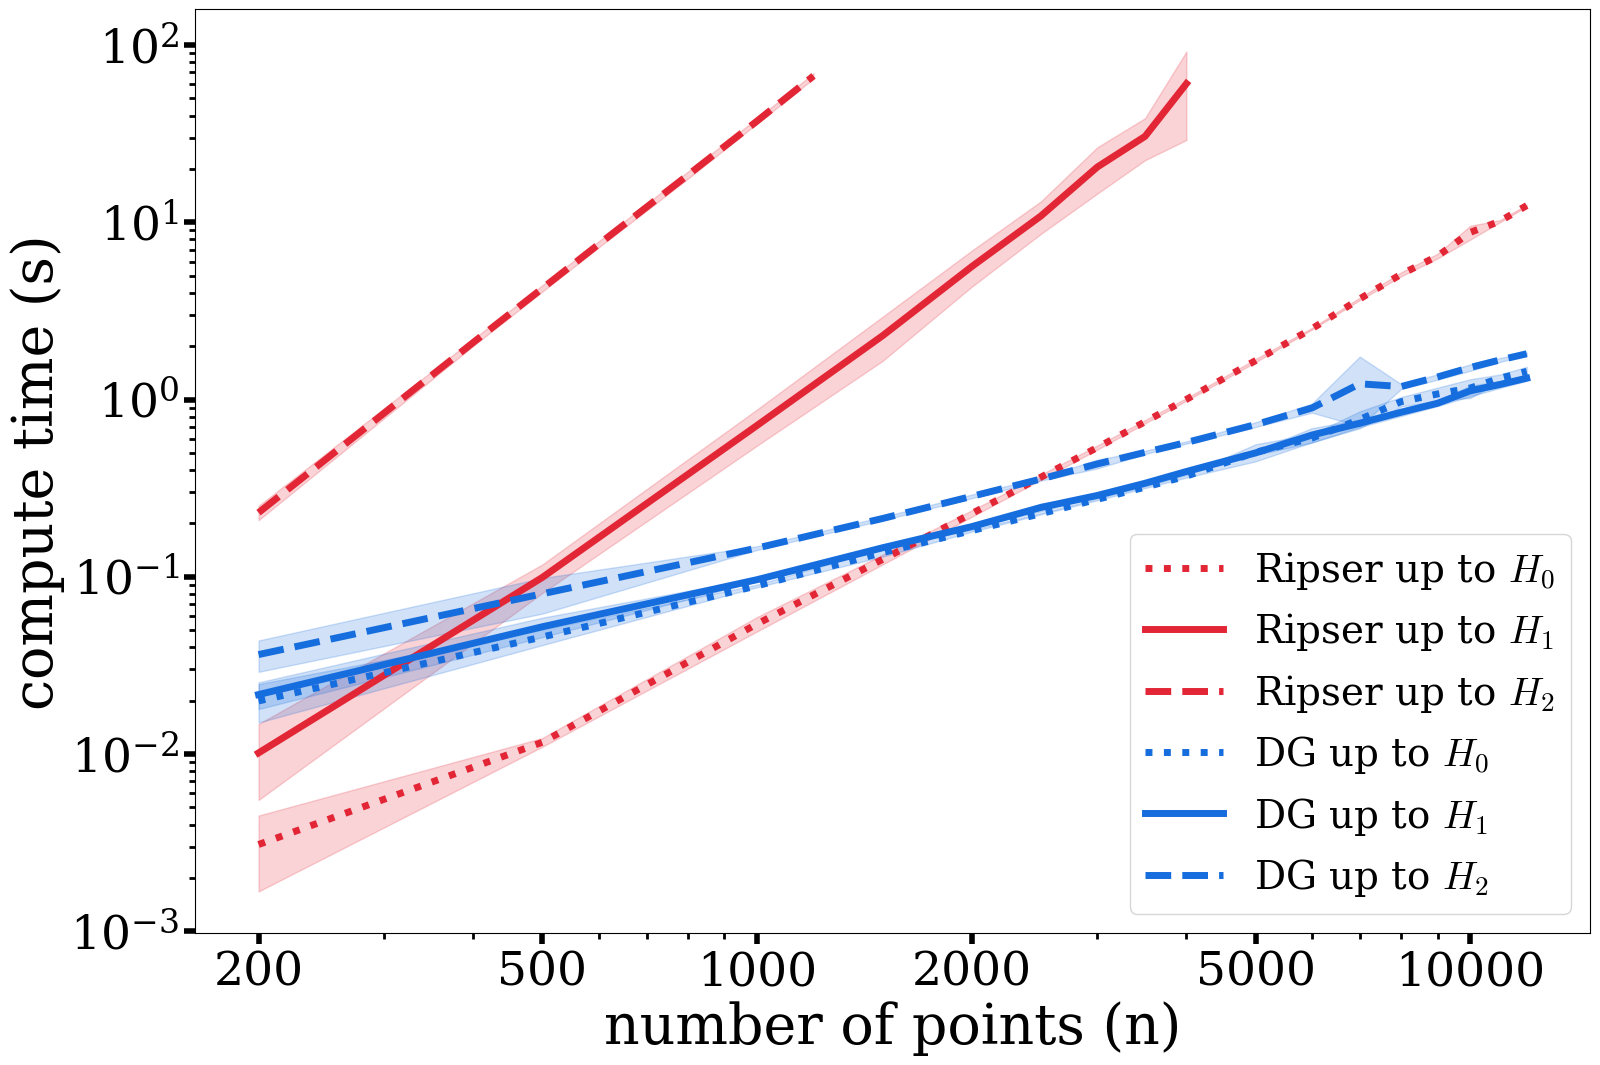

In [ ]:


def plot_with_error_scaling(ax, x, y, dy, label=None, color=None, alpha=0.2, linestyle='-', linewidth=5):
    x = np.array(x)
    y = np.array(y)
    dy = np.array(dy)

    ax.plot(x, y, label=label, color=color, linestyle=linestyle, linewidth=linewidth)
    ax.fill_between(
        x,
        y - dy,
        y + dy,
        alpha=alpha,
        color=color
    )

fig, ax1 = plt.subplots(1, 1, figsize=(18, 12))

def draw_res(filepath, ax, label, color, linestyle='-'):
    h_1_res, df = analyse_benchmark(filepath)
    # print(h_1_res)
    dg_x = h_1_res['n'].tolist()
    # print(dg_x)
    dg_y = h_1_res['mean'].tolist()
    dg_dy = h_1_res['std'].tolist()
    plot_with_error_scaling(ax, dg_x, dg_y, dg_dy, color=color, label=label, linestyle=linestyle, 
                            )

draw_res("benchmarks/ripser_H_0_n_scaling.csv", ax1, r"Ripser up to $H_0$", dot_colors[0], linestyle=':')
draw_res("benchmarks/ripser_H_1_n_scaling.csv", ax1, r"Ripser up to $H_1$", dot_colors[0], linestyle='-')
draw_res("benchmarks/ripser_H_2_n_scaling.csv", ax1, r"Ripser up to $H_2$", dot_colors[0], linestyle='--')

draw_res("benchmarks/dg_H_0_n_scaling.csv", ax1, r"DG up to $H_0$", dot_colors[1], linestyle=':')
draw_res("benchmarks/dg_H_1_n_scaling.csv", ax1, r"DG up to $H_1$", dot_colors[1], linestyle='-')
draw_res("benchmarks/dg_H_2_n_scaling.csv", ax1, r"DG up to $H_2$", dot_colors[1], linestyle='--')



ax1.set_yscale("log")
ax1.set_ylabel("compute time (s)")
ax1.set_xlabel("number of points (n)")
# bottom right

# ax1.set_title("Scaling of Ripser and DG Computation with n")
ax1.set_xscale('log')
ticks = [200, 500, 1000, 2000, 5000, 10000] 
ax1.set_xticks(ticks)
ax1.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())

label_size = 40
ax1.tick_params(axis='both', which='major', labelsize=label_size)
ax1.xaxis.label.set_size(label_size)
ax1.yaxis.label.set_size(label_size)

ticks_size = 34
ax1.tick_params(axis='both', which='major', labelsize=ticks_size, width=4, length=8)
ax1.tick_params(axis='both', which='minor', labelsize=ticks_size, width=2, length=4)

legend_size = 28
ax1.legend(loc='lower right', fontsize=legend_size)


plt.savefig("../figures/figs/benchmarking_n_scaling.pdf")

plt.show()






In [ ]:
# unpickle /Users/landa/Documents/GitHub/DG_new/figures/benchmarking_results/dg_dim.pkl
import pickle
with open("../figures/benchmarking_results/dg_dim.pkl", "rb") as f:
    dim_benchmark = pickle.load(f)


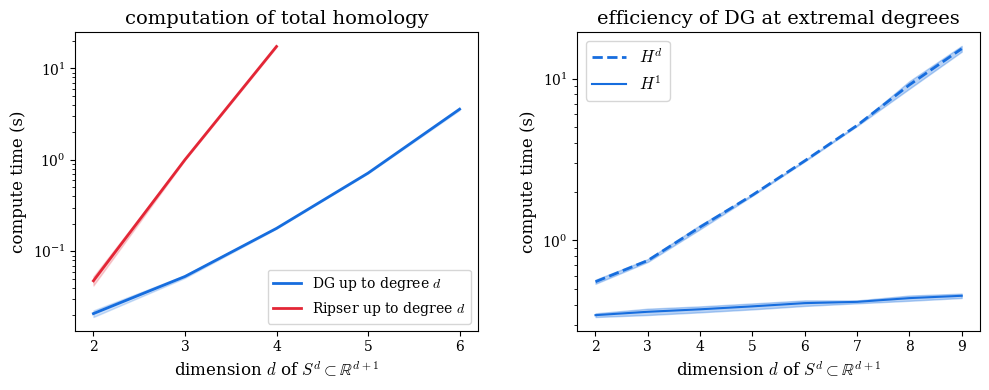

In [ ]:
import json
import pickle
def load_benchmark(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

dg_cum_bench = load_benchmark("benchmarks/dg_dim.pkl")
ripser_cum_bench = load_benchmark("benchmarks/risper_dim.pkl")

cutoff = 5
line_width = 2


plot_with_error_scaling(
    ax1,
    dg_cum_bench["params"][:cutoff],
    dg_cum_bench["mean"][:cutoff],
    dg_cum_bench["std"][:cutoff],
    color=dot_colors[1],
    label=r"DG up to degree $d$",
    linewidth=line_width,
)
plot_with_error_scaling(
    ax1,
    ripser_cum_bench["params"],
    ripser_cum_bench["mean"],
    ripser_cum_bench["std"],
    color=dot_colors[0],
    label=r"Ripser up to degree $d$",
    linewidth=line_width,
)

ax1.set_xticks([2,3,4,5,6])
ax1.set_yscale("log")
ax1.set_ylabel("compute time (s)")
ax1.set_xlabel(r"dimension $d$ of $S^d\subset\mathbb{R}^{d+1}$")
ax1.legend()


label_size = 12
# change tick label size
ax1.tick_params(axis='both', which='major', labelsize=label_size-2)
ax2.tick_params(axis='both', which='major', labelsize=label_size-2)
# change axis label size
ax1.xaxis.label.set_size(label_size)
ax1.yaxis.label.set_size(label_size)
ax2.xaxis.label.set_size(label_size)
ax2.yaxis.label.set_size(label_size)


with open("times.json") as f:
    raw = json.load(f)

times_by_pair = {
    tuple(map(int, k.split(","))): v
    for k, v in raw.items()
}

dims = []
means = []
stds = []

for (degree, ambient_dim), times in sorted(times_by_pair.items()):
    dims.append(ambient_dim)
    means.append(np.mean(times))
    stds.append(np.std(times))

results = load_benchmark("benchmarks/isolated_degrees.pkl")

dims2 = []
means2 = []
std2s = []
for key in sorted(results.keys()):
    dims2.append(results[key]["ambient_dim"])
    means2.append(results[key]["mean"])
    std2s.append(results[key]["std"])


# ticks_size = 14
# labels_size = 16




alpha=0.3
ax2.plot(dims, means,linestyle='--', color=dot_colors[1], label=r"$H^d$", linewidth=line_width)
ax2.fill_between(
    dims,
    np.array(means) - np.array(stds),
    np.array(means) + np.array(stds),
    alpha=alpha,
    color=dot_colors[1]
)

ax2.plot(dims2, means2, linestyle='-', color=dot_colors[1], label=r"$H^1$")
ax2.fill_between(
    dims2,
    np.array(means2) - np.array(std2s),
    np.array(means2) + np.array(std2s),
    alpha=alpha,
    color=dot_colors[1]
)


ax2.set_xlabel(r"dimension $d$ of $S^d\subset\mathbb{R}^{d+1}$")
ax2.set_ylabel("compute time (s)", fontsize=label_size)
ax2.set_title("efficiency of DG at extremal degrees", fontsize=label_size+2)
ax1.set_title("computation of total homology", fontsize=label_size+2)
#change title size

# plt.grid(True)
ax2.legend(fontsize=label_size)
ax2.set_yscale('log')
plt.tight_layout(w_pad=3.0)
plt.savefig("../figures/figs/benchmark_d_scaling.pdf")
plt.show()
